In [ ]:
# Librairies :
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller , kpss 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model



In [11]:
# Première étape : importation et néttoyage des variables (Typage/Valeur manquantes/Alignement temporel/Suppression du surplus)

df_micron = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "Micron") # on définit la variable au fichier xlsx via panda (df = DataFrame)
df_micron = df_micron[['Date','Dernier']] # On ne garde que la date et le prix (on élimine le surplus)
df_micron.rename(columns={'Dernier':'Price_MU'},inplace=True) # On rename la colonne Dernier (inplace évite de dupliquer inutilement donc économie de mémoire)
df_micron.set_index('Date',inplace=True) # Permet de définir cette colonne en index officiel du DataFrame 

df_sox = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "SOX Index") 
df_sox = df_sox[['Date','Dernier']] 
df_sox.rename(columns={'Dernier':'Price_SOX'},inplace=True)
df_sox.set_index('Date',inplace=True)

df_nvidia = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "NVIDIA")
df_nvidia = df_nvidia[['Date','Dernier']]
df_nvidia.rename(columns={'Dernier':'Price_NVIDIA'},inplace=True)
df_nvidia.set_index('Date',inplace=True)

df_fx = pd.read_excel("Projet Économétrique.xlsx", sheet_name = "USDKRW")
df_fx = df_fx[['Date','Dernier']]
df_fx.rename(columns={'Dernier':'USD_KRW'},inplace=True)
df_fx.set_index('Date',inplace=True)

df_vix = pd.read_excel("Projet Économétrique.xlsx", sheet_name="VIX")
df_vix = df_vix[['Date','Dernier']]
df_vix.rename(columns={'Dernier':'VIX'},inplace=True)
df_vix.set_index("Date",inplace=True)

# df_micron.info() # pour déterminer la nature de chaque données
# df_micron.head() # Permet de lire un échantillon de la variable, on peut modifier head(10) pour les 10 premiers (par défaut 5)

In [12]:
# Alignement temporel 

df_final = pd.concat([df_micron , df_sox , df_nvidia , df_fx , df_vix], axis=1 , join='outer', sort=False) # Concaténation des DataFrames, 
# axis=1 pour fusion horizontale
# join='outer' pour vérifier si une variable no possède pas de cotation à chaque date t
# sort=False pour désactiver le tri implicite de panda (lourd en ressoource)

df_final.sort_index(inplace=True) # On ordonne les valeurs temporel 

df_final.isnull().sum() # On regarde combien de NaN (Not a Number) (donc combien de dates ne sont pas cotés)

# Traitement des valeurs manquantes 
# Méthode choisie : suppression des NaN (+ de précision, représente que 4% de l'échantillon)

df_final.dropna(inplace=True) # Élimine toute ligne t contenant un NaN sur l'une des variables

df_final.shape # Donne la taille de la matrice finale 

# Nettoyage terminé.

(2553, 5)

In [13]:
# Convertion des prix en rendements logarithmes pour stationnariser (Utilisation de numpy ici pour ln)

# df_final['Price_MU'] -> Pt 
# df_final['Price_MU'].shift(1) -> Pt -1 

# Rt = ln(Pt / Pt-1) = ln(Pt) - ln(Pt-1)

df_final['rt_mu'] = np.log(df_final['Price_MU']) - np.log(df_final['Price_MU'].shift(1)) # On définit dans df_final un vecteur des rendements pour mu
df_final['rt_sox'] = np.log(df_final['Price_SOX']) - np.log(df_final['Price_SOX'].shift(1))
df_final['rt_nvidia'] = np.log(df_final['Price_NVIDIA']) - np.log(df_final['Price_NVIDIA'].shift(1))
df_final['rt_fx'] = np.log(df_final['USD_KRW']) - np.log(df_final['USD_KRW'].shift(1))
df_final['d_vix'] = df_final['VIX'] - df_final['VIX'].shift(1) # Ici différenciation simple 

df_final.dropna(inplace=True) # On supprime la première ligne de NaN 

df_final.head()

,Price_MU,Price_SOX,Price_NVIDIA,USD_KRW,VIX,rt_mu,rt_sox,rt_nvidia,rt_fx,d_vix
Date,,,,,,,,,,
2016-01-05,14.82,649.5,0.82,1189.81,19.34,0.033622,-0.010415,0.012270,0.000387,-1.36
2016-01-06,14.22,631.2,0.79,1199.52,20.59,-0.041328,-0.028580,-0.037271,0.008128,1.25
2016-01-07,13.66,610.2,0.76,1196.29,24.99,-0.040178,-0.033836,-0.038715,-0.002696,4.40
2016-01-08,13.33,600.5,0.74,1206.94,27.01,-0.024455,-0.016024,-0.026668,0.008863,2.02
2016-01-11,12.53,603.5,0.74,1203.76,24.30,-0.061891,0.004983,0.000000,-0.002638,-2.71


In [14]:
# Test Augmented Dickey-Fuller (Utilisation de statsmodels ici)

variables = ['rt_mu','rt_sox','rt_nvidia','rt_fx','d_vix']

print("--- Tests ADF (H0: Non-Stationnaire) ---")
for var in variables:
    pval_adf = adfuller(df_final[var])[1] # Le 1 désigne le 2 ème élément de sortie de adfuller 
    print(f"{var} : p-value = {pval_adf}") # f permet d'implémenter de manière plus simple/lisible les variables

# Test kpss

print("\n --- Tests kpss (H0: Stationnaire) ---")
for var in variables:
    pval_kpss = kpss(df_final[var])[1]
    print(f"{var} : p-value = {pval_kpss}") 

# Utilisation de deux tests afin d'augmenter la robustesse via des angles opposés.

--- Tests ADF (H0: Non-Stationnaire) ---
rt_mu : p-value = 7.630005801247457e-28
rt_sox : p-value = 2.3682736666951642e-27
rt_nvidia : p-value = 2.48015690696638e-30
rt_fx : p-value = 0.0
d_vix : p-value = 2.1878827481853448e-30

 --- Tests kpss (H0: Stationnaire) ---
rt_mu : p-value = 0.1
rt_sox : p-value = 0.1
rt_nvidia : p-value = 0.1
rt_fx : p-value = 0.1
d_vix : p-value = 0.1


C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  pval_kpss = kpss(df_final[var])[1]
C:\Users\mateo\AppData\Local\Temp\ipykernel_6296\604249518.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-va

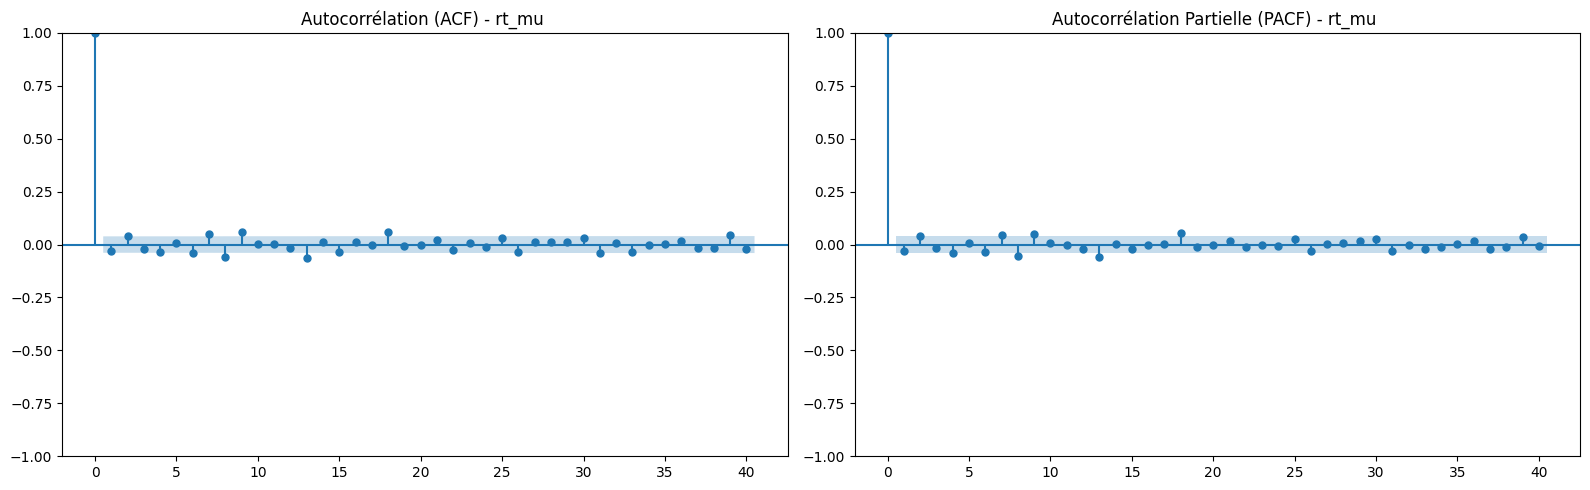

In [15]:
# Identification du modèle ARMA(p,q) via ACF & PACF (avant d'extraire les résidus pour un modèle GARCH)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,5)) # On définit la zone des graphiques

plot_acf(df_final['rt_mu'], ax=ax1, lags=40, title="Autocorrélation (ACF) - rt_mu ") 
plot_pacf(df_final['rt_mu'], ax=ax2, lags=40, title="Autocorrélation Partielle (PACF) - rt_mu ")

plt.tight_layout() # Mieux visuellement 
plt.show() 

# On observe aucun retard significatif donc modèle de type ARMA(0,0) (bruit blanc faible)

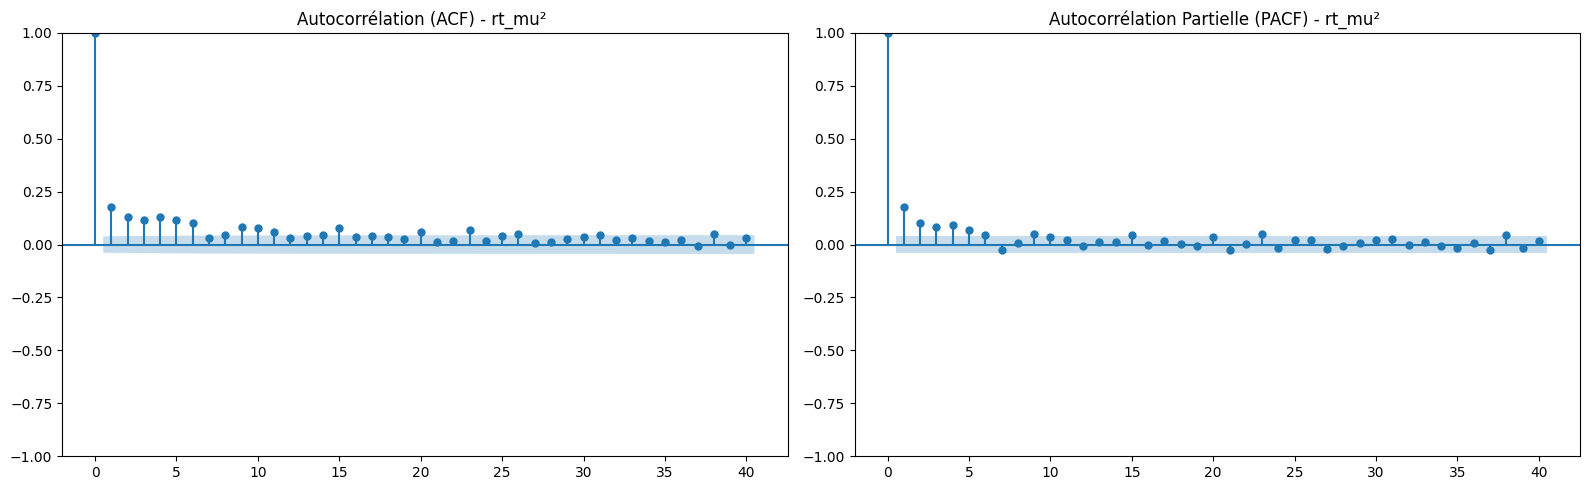

In [16]:
# Tests des effets ARCH (hétéroscédasticité conditionnelle) pour analyser visuellement la volatilité

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,5))

plot_acf(df_final['rt_mu']**2,ax=ax1,lags=40,title="Autocorrélation (ACF) - rt_mu² ")

plot_pacf(df_final['rt_mu']**2,ax=ax2,lags=40,title="Autocorrélation Partielle (PACF) - rt_mu² ")

plt.tight_layout()
plt.show()


In [ ]:
# Test d'Engle (ARCH-LM) (hétéroscédasticité conditionnelle) pour analyser statistiquement la volatilité avant modélisation d'un modèle GARCH

residus_rt_mu = df_final['rt_mu'] - df_final['rt_mu'].mean() # mean renvoie la moyenne empirique, ici on isole les résidus du ARMA(0,0)

stat_lm, pval_lm, _ , _ = het_arch(residus_rt_mu, nlags=5) # on assigne à la sortie de het_arch les 4 variables 
# nlags = 5 pour les 5 jours de la semaine (ddl)
# stat_lm = multiplicateur de lagrange (LM = T x R²)
# pval_lm = p-value du test LM 

print("--- Test ARCH-LM d'Engle ---")
print(f"Statistique du test (LM) : {stat_lm}") # TODO: Ajouter ici et dans les print des résultats de test des if pour comparer avec la valeur de la table ?
print(f"p-value (LM : {pval_lm})")

# Rejet de H0 donc : On observe ici une forte hétéroscédasticité conditionnelle -> Obligation utilisation modèle GARCH
# /!\ Dans GARCH p = Le nombre de retard de la variance passée / q = le nombre de retard des chocs passés au carré
# /!\ En Python on inverse GARCH(q,p)
# Rappel : Dans ARMA p = Nombre de retard de la série elle même / q = le nombre de retard des erreurs


--- Test ARCH-LM d'Engle ---
Statistique du test (LM) : 154.99332492847986
p-value (LM : 1.154234454252436e-31)


In [ ]:
# Estimation du modèle GARCH


